Combining bulk and VLP sequencing data, vOTUs with the following replication signatures were identified:
1. vOTU/host MAG mean coverage (bulk) > 1.75
2. vOTU/host MAG mean coverage (VLP) > 1.75
3. vOTU mean coverage (VLP) > median + 2*IQR of non-viral contigs
4. vOTU VLP/bulk RPKM ratio > median + 2*IQR of non-viral contigs

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

replication_signature_cols = [
    'covratio_bulk_signature',
    'covratio_vlp_signature',
    'covmean_vlp_signature',
    'RPKM_ratio_signature'
]
replication_signature_labels = [
    'phage/host coverage (bulk)',
    'phage/host coverage (VLP)',
    'outlier coverage (VLP)',
    'outlier VLP/bulk coverage'
]

sns.set_style('whitegrid')
sns.set_palette('deep')

phyla1 = ['Firmicutes','Bacteroidota','Actinobacteriota','Proteobacteria']
hue_order = phyla1 + ['Others']
palette = ['C3','C2','C0','C1','grey']

In [2]:
df_v = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id','VFC'])
df_vc = pd.read_excel('../data/Supplementary_Data_3_VFC_metadata.xlsx', usecols=['VFC','VC_size','perc_prevalence','primary_host_phylum','perc_vOTUs_replicating','perc_samples_replicating'])

df = pd.read_excel('../data/Supplementary_Data_8_RPKM_ratios_and_replication_signatures_of_vOTUs.xlsx', sheet_name='vOTU replication signatures')
df = df.merge(df_v, on='votu_id', how='left').merge(df_vc[['VFC','VC_size']], on='VFC', how='left')

### Fig. 3B: % of replicating vOTUs in the top VFCs

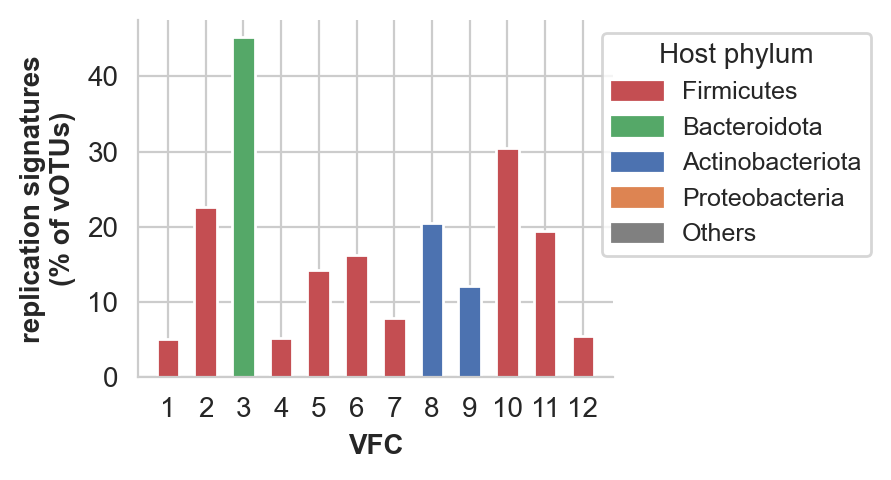

In [3]:
df_topvfc_plot = df_vc[df_vc['VFC'].isin(range(1,13))].copy()

fig, ax = plt.subplots(figsize=(4.5, 2.5), dpi=200)

color_map = dict(zip(hue_order, palette))
bar_colors = df_topvfc_plot['primary_host_phylum'].map(color_map)

ax.bar(range(12), df_topvfc_plot['perc_vOTUs_replicating'], width=0.6, color=bar_colors, alpha=1)

ax.set_xlim(-0.8, 11.8)
ax.set_xticks(range(12), range(1,13))
ax.set_ylabel('replication signatures\n(% of vOTUs)', fontweight='bold')
ax.set_xlabel('VFC', fontweight='bold')

handles = [plt.Rectangle((0,0),1,1, color=color_map[p]) for p in hue_order]
ax.legend(handles, hue_order, title='Host phylum', bbox_to_anchor=(0.95, 1), loc='upper left', fontsize=9)

plt.tight_layout()
sns.despine()

### Fig. 3C: VFC prevalence vs. % of samples with replication signatures

In [4]:
df_plot = df_vc[df_vc.VC_size > 1].copy() # non-singleton VFCs
df_plot['phylum_plot'] = df_plot['primary_host_phylum'].where(df_plot['primary_host_phylum'].isin(phyla1), 'Others')

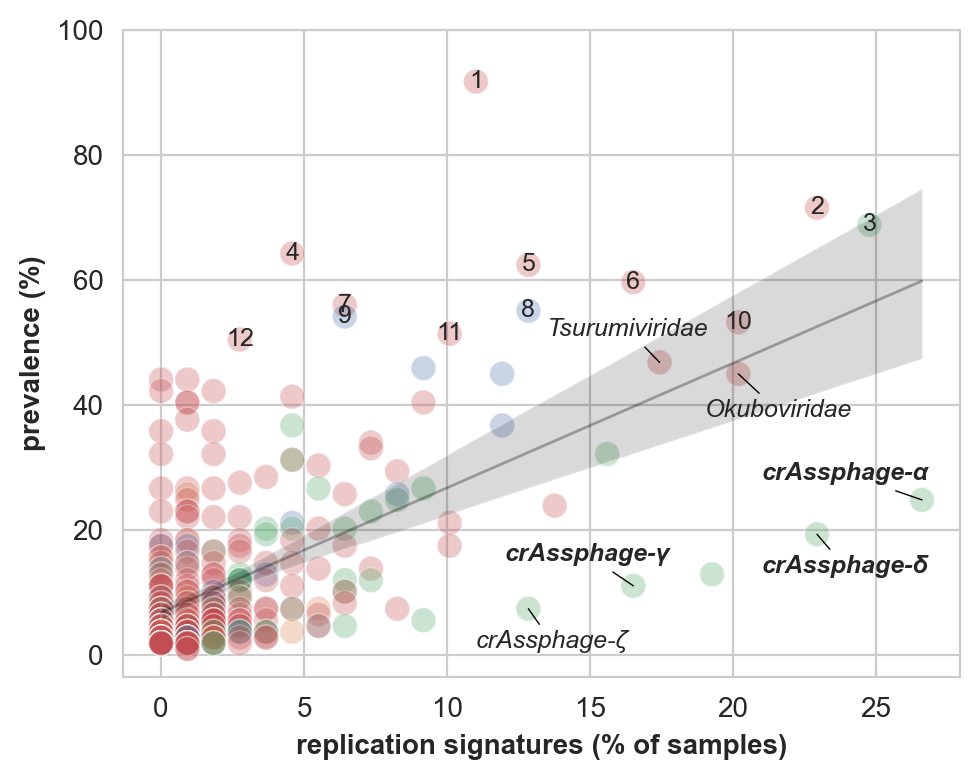

In [5]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)

sns.scatterplot(data=df_plot, x='perc_samples_replicating', y='perc_prevalence',
                hue='phylum_plot', hue_order=hue_order, palette=palette,
                s=80, linewidth=0.5, alpha=0.3, ax=ax)

sns.regplot(
    data=df_plot,
    x='perc_samples_replicating',
    y='perc_prevalence',
    scatter=False,
    ci=95,
    color='black',
    line_kws={'lw': 1, 'alpha': 0.3},
    ax=ax
)

plt.xlabel('replication signatures (% of samples)', fontweight='bold')
plt.ylabel('prevalence (%)', fontweight='bold')

y1,y2 = ax.get_ylim()
ax.set_ylim(y1,100)

for _, row in df_plot[df_plot['VFC'].isin(range(1,13))].iterrows():
    x = row['perc_samples_replicating']
    y = row['perc_prevalence']
    ax.text(x , y, str(int(row['VFC'])),
            fontsize=9, ha='center', va='center')

ax.annotate('crAssphage-α', xy=(26.605505, 24.770642), xytext=(21, 28), fontsize=9, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('crAssphage-δ', xy=(22.935780, 19.266055), xytext=(21, 13), fontsize=9, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('crAssphage-γ', xy=(16.513761, 11.009174), xytext=(12, 15), fontsize=9, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('crAssphage-ζ', xy=(12.844037, 7.339450), xytext=(11, 1), fontsize=9, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Tsurumiviridae', xy=(17.431193, 46.788991), xytext=(13.5, 51), fontsize=9, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Okuboviridae', xy=(20.183486, 44.954128), xytext=(19, 38), fontsize=9, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )

ax.legend_.remove()
plt.tight_layout()

### Supplementary Fig. 21: Venn diagram of replication signatures for vOTU-sample pairs

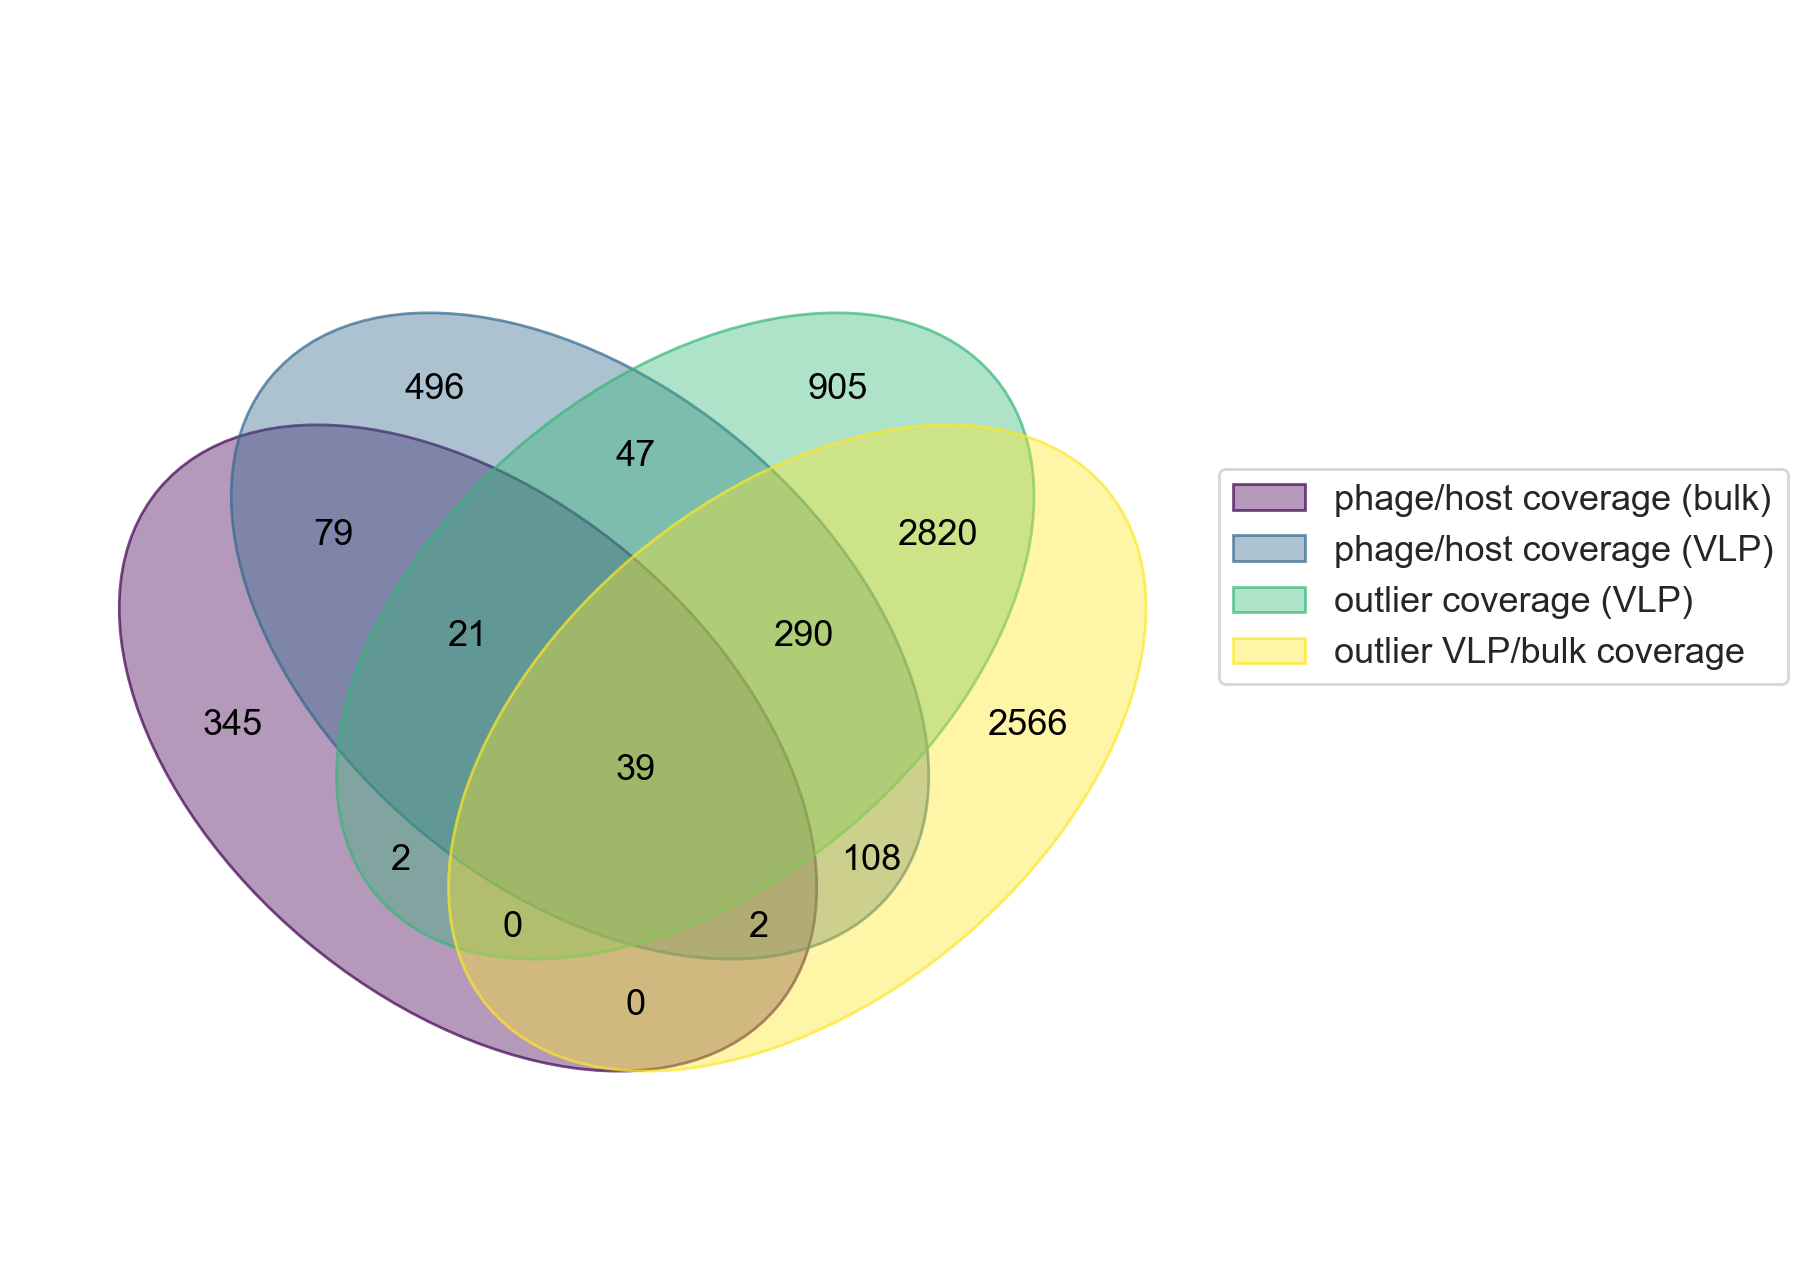

In [6]:
sets = {replication_signature_labels[i]: set(df[df[replication_signature_cols[i]] == 1][['votu_id','sample_id']].apply(tuple, axis=1)) for i in range(len(replication_signature_cols))}

from venn import venn

fig, ax = plt.subplots(figsize=(8,8), dpi=200)

venn(sets, ax=ax)

leg = ax.get_legend()
leg.set_bbox_to_anchor((1.45, 0.65))

"All pairs of measures have non-random overlaps (two-sided Fisher’s exact test with FDR correction)."

In [7]:
from itertools import combinations
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

universe = set().union(*sets.values())
N = len(universe)

results = []
for (k1, s1), (k2, s2) in combinations(sets.items(), 2):
    a = len(s1 & s2)
    b = len(s1 - s2)
    c = len(s2 - s1)
    d = N - (a + b + c)
    
    oddsratio, pvalue = fisher_exact([[a, b], [c, d]], alternative='two-sided')
    
    results.append({
        'Set1': k1,
        'Set2': k2,
        'a_overlap': a,
        'b_only_s1': b,
        'c_only_s2': c,
        'd_neither': d,
        'OddsRatio': oddsratio,
        'Pvalue': pvalue
    })

df_results = pd.DataFrame(results)

rejected, pvals_corrected, _, _ = multipletests(df_results['Pvalue'], method='fdr_bh')

df_results['Pvalue_FDR'] = pvals_corrected
df_results['Significant_FDR'] = rejected

print(df_results)

                         Set1                       Set2  a_overlap  \
0  phage/host coverage (bulk)  phage/host coverage (VLP)        141   
1  phage/host coverage (bulk)     outlier coverage (VLP)         62   
2  phage/host coverage (bulk)  outlier VLP/bulk coverage         41   
3   phage/host coverage (VLP)     outlier coverage (VLP)        397   
4   phage/host coverage (VLP)  outlier VLP/bulk coverage        439   
5      outlier coverage (VLP)  outlier VLP/bulk coverage       3149   

   b_only_s1  c_only_s2  d_neither  OddsRatio         Pvalue     Pvalue_FDR  \
0        347        941       6291   2.716562   8.777387e-19   1.053286e-18   
1        426       4062       3170   0.113580   5.218517e-84   1.043703e-83   
2        447       5784       1448   0.022962  1.425863e-236  8.555180e-236   
3        685       3727       2911   0.452671   1.262132e-32   1.893197e-32   
4        643       5386       1252   0.158705  1.773046e-157  5.319139e-157   
5        975       2676     

### Supplementary Fig. 22: % of replicating vOTUs by replication signature in the top VFCs

In [8]:
df1 = df.groupby(['VFC','votu_id'], as_index=False).agg({r: 'max' for r in replication_signature_cols} | {'VC_size': 'first'})
df2 = df1.groupby('VFC', as_index=False).agg({r: 'sum' for r in replication_signature_cols} | {'VC_size': 'first'})

for r in replication_signature_cols:
    df2[f'perc_vOTUs_{r}'] = df2[r]/df2.VC_size*100

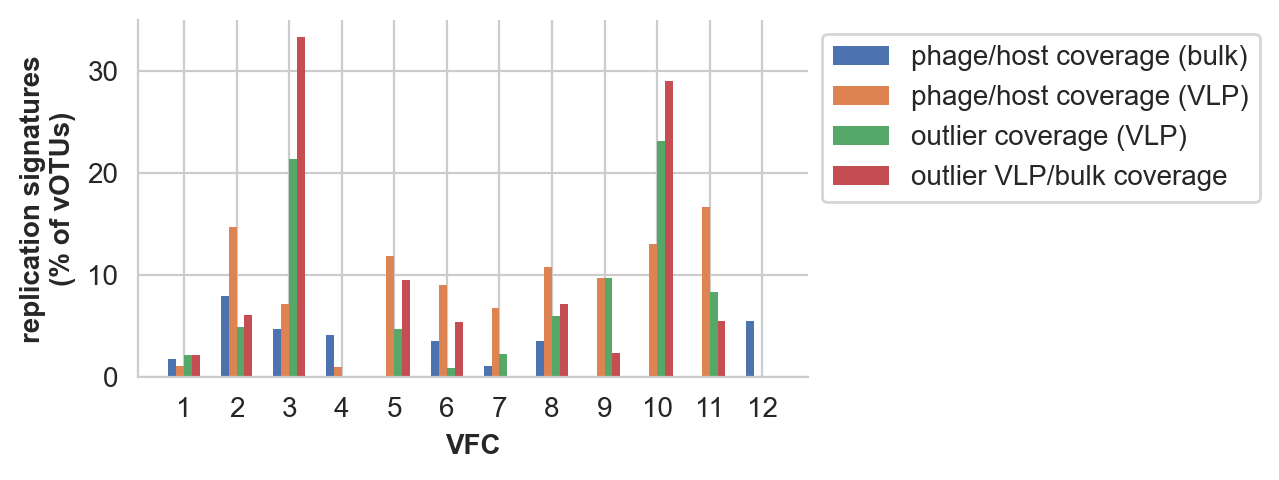

In [9]:
df_topvfc_plot = df2[df2['VFC'].isin(range(1,13))]

fig, ax = plt.subplots(figsize=(6.5, 2.5), dpi=200)

width = 0.15
for i, r in enumerate(replication_signature_cols):
    ax.bar(np.arange(12) + i*width - (len(replication_signature_cols)-1)/2 * width, df_topvfc_plot[f'perc_vOTUs_{r}'], width, label=replication_signature_labels[i], linewidth=0)

ax.set_xticks(range(12), range(1,13))
ax.set_xlabel('VFC', fontweight='bold')
ax.set_ylabel('replication signatures\n(% of vOTUs)', fontweight='bold')
ax.legend(title='', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
sns.despine()